# Lab Work: Developing and Comparing AI Models for Android Malware Detection

## Objective:
The goal of this lab is to develop and evaluate multiple AI models for detecting Android malware using the provided Android Malware Dataset. Students will choose at least three different machine learning or deep learning algorithms to compare their performance in classifying Android applications as benign or malicious.

## Dataset Overview:
The **Android Malware Dataset for Machine Learning** contains labeled Android APK samples, classified as benign (goodware) or malicious (e.g., adware, spyware, trojans). It includes various features extracted from the APKs, such as requested permissions, API calls, system behaviors, and more, which can be used to train machine learning models.

## Tasks:

1. **Data Preprocessing**:
   - Load the dataset and clean it by handling missing values and converting categorical features into numerical ones if necessary.
   - Split the data into training and testing sets.

2. **Model Development**:
   - Choose at least **three AI algorithms** of your choice (e.g., Logistic Regression, Random Forest, SVM, Neural Networks, XGBoost, etc.).
   - Train each model on the dataset and evaluate their performance using accuracy, precision, recall, F1-score, and confusion matrix.

3. **Model Comparison**:
   - Compare the models based on their performance metrics.
   - Analyze which model performs best and why.

4. **Optional (Hyperparameter Tuning)**:
   - Optionally, apply techniques like grid search to optimize the model’s hyperparameters.


## Resources:
- Kaggle Dataset: [Android Malware Dataset for Machine Learning](https://www.kaggle.com/datasets/shashwatwork/android-malware-dataset-for-machine-learning)

You need to login in Kaggle to get access to the dataset.


In [ ]:
#
#
#
#
# Your code to develop AI model for malware classification.
# Hint: Use the example code provided in previous lab.
#
#
#
#

1. Import libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

2. Load dataset

In [ ]:
df = pd.read_csv("drebin-215-dataset-5560malware-9476-benign.csv")
df.head()

/tmp/ipykernel_2767/3976921972.py:1: DtypeWarning: Columns (92) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("drebin-215-dataset-5560malware-9476-benign.csv")


,transact,onServiceConnected,bindService,attachInterface,ServiceConnection,android.os.Binder,SEND_SMS,Ljava.lang.Class.getCanonicalName,Ljava.lang.Class.getMethods,Ljava.lang.Class.cast,...,READ_CONTACTS,DEVICE_POWER,HARDWARE_TEST,ACCESS_WIFI_STATE,WRITE_EXTERNAL_STORAGE,ACCESS_FINE_LOCATION,SET_WALLPAPER_HINTS,SET_PREFERRED_APPLICATIONS,WRITE_SECURE_SETTINGS,class
0,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,S
1,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,S
2,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,S
3,0,0,0,0,0,0,0,0,0,1,...,0,0,0,1,1,1,0,0,0,S
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,1,0,0,0,S


In [ ]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15036 entries, 0 to 15035
Columns: 216 entries, transact to class
dtypes: int64(214), object(2)
memory usage: 24.8+ MB


,0
transact,0
onServiceConnected,0
bindService,0
attachInterface,0
ServiceConnection,0
...,...
ACCESS_FINE_LOCATION,0
SET_WALLPAPER_HINTS,0
SET_PREFERRED_APPLICATIONS,0
WRITE_SECURE_SETTINGS,0


In [ ]:
print(df.columns.tolist())

['transact', 'onServiceConnected', 'bindService', 'attachInterface', 'ServiceConnection', 'android.os.Binder', 'SEND_SMS', 'Ljava.lang.Class.getCanonicalName', 'Ljava.lang.Class.getMethods', 'Ljava.lang.Class.cast', 'Ljava.net.URLDecoder', 'android.content.pm.Signature', 'android.telephony.SmsManager', 'READ_PHONE_STATE', 'getBinder', 'ClassLoader', 'Landroid.content.Context.registerReceiver', 'Ljava.lang.Class.getField', 'Landroid.content.Context.unregisterReceiver', 'GET_ACCOUNTS', 'RECEIVE_SMS', 'Ljava.lang.Class.getDeclaredField', 'READ_SMS', 'getCallingUid', 'Ljavax.crypto.spec.SecretKeySpec', 'android.intent.action.BOOT_COMPLETED', 'USE_CREDENTIALS', 'MANAGE_ACCOUNTS', 'android.content.pm.PackageInfo', 'KeySpec', 'TelephonyManager.getLine1Number', 'DexClassLoader', 'HttpGet.init', 'SecretKey', 'Ljava.lang.Class.getMethod', 'System.loadLibrary', 'android.intent.action.SEND', 'Ljavax.crypto.Cipher', 'WRITE_SMS', 'READ_SYNC_SETTINGS', 'AUTHENTICATE_ACCOUNTS', 'android.telephony.gsm.

In [ ]:
print(df["class"].unique())

['S' 'B']


3. Data processing

- Handle missing values

In [ ]:
df = df.dropna()

In [ ]:
df = df.replace('?', np.nan)

In [ ]:
X = df.drop("class", axis=1)
y = df["class"]

In [ ]:
y = y.map({'S':0, 'B':1})

In [ ]:
X = X.apply(pd.to_numeric, errors='coerce')
X = X.fillna(X.median())

4. Train test split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

5. Feature scaling

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

6. Model 1 - Logistic Regression

In [ ]:
lr = LogisticRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, y_pred_lr))

print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.9780585106382979
[[1104   41]
 [  25 1838]]
              precision    recall  f1-score   support

           0       0.98      0.96      0.97      1145
           1       0.98      0.99      0.98      1863

    accuracy                           0.98      3008
   macro avg       0.98      0.98      0.98      3008
weighted avg       0.98      0.98      0.98      3008



7. Model 2 RANDOM FOREST

In [ ]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:",
      accuracy_score(y_test, y_pred_rf))

print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.9867021276595744
[[1117   28]
 [  12 1851]]
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      1145
           1       0.99      0.99      0.99      1863

    accuracy                           0.99      3008
   macro avg       0.99      0.98      0.99      3008
weighted avg       0.99      0.99      0.99      3008



8. Model 3 - Support Vector Machine


In [ ]:
svm = SVC()
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

print("SVM Accuracy:",
      accuracy_score(y_test, y_pred_svm))

print(confusion_matrix(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.980718085106383
[[1103   42]
 [  16 1847]]
              precision    recall  f1-score   support

           0       0.99      0.96      0.97      1145
           1       0.98      0.99      0.98      1863

    accuracy                           0.98      3008
   macro avg       0.98      0.98      0.98      3008
weighted avg       0.98      0.98      0.98      3008



COMPARISON TABLE

In [ ]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "SVM"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_svm)
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.978059
1,Random Forest,0.986702
2,SVM,0.980718


**Hyperparameter Tununing**

In [ ]:
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators':[50,100],
    'max_depth':[5,10,None]
}

grid = GridSearchCV(RandomForestClassifier(),
                    params,
                    cv=3)

grid.fit(X_train, y_train)

print(grid.best_params_)

{'max_depth': None, 'n_estimators': 100}


In [ ]:
# GRAPHS

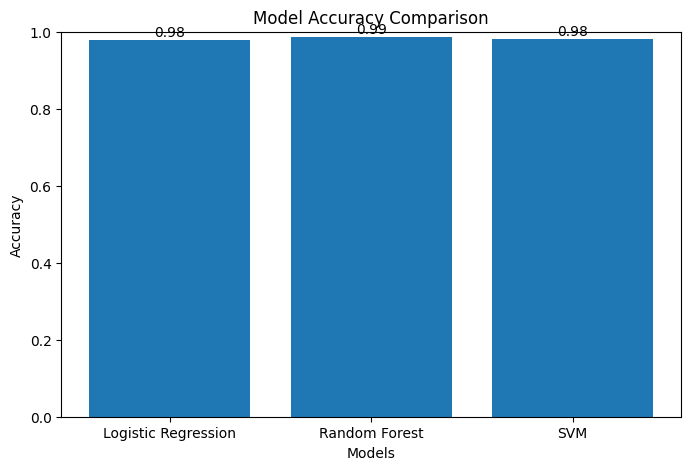

In [ ]:
models = ["Logistic Regression", "Random Forest", "SVM"]
accuracies = [
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_rf),
    accuracy_score(y_test, y_pred_svm)
]

plt.figure(figsize=(8,5))
plt.bar(models, accuracies)
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.ylim(0, 1.0)

for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')

plt.show()

PREcision, recall & F1 Score

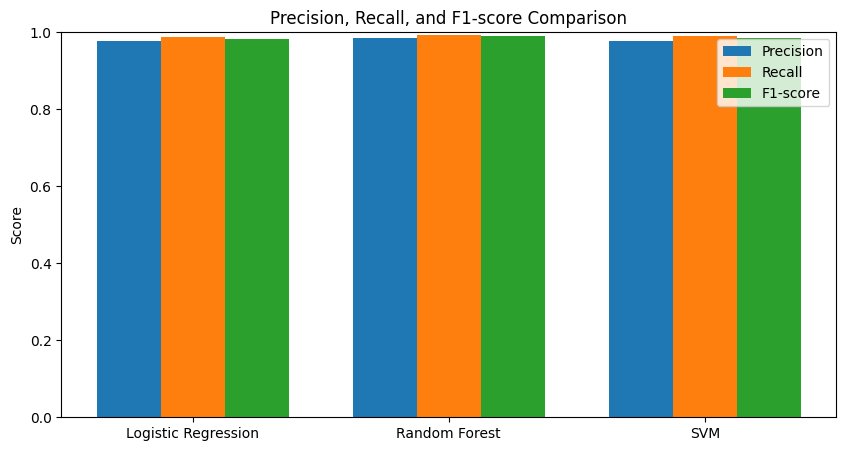

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np

precision_scores = [
    precision_score(y_test, y_pred_lr),
    precision_score(y_test, y_pred_rf),
    precision_score(y_test, y_pred_svm)
]

recall_scores = [
    recall_score(y_test, y_pred_lr),
    recall_score(y_test, y_pred_rf),
    recall_score(y_test, y_pred_svm)
]

f1_scores = [
    f1_score(y_test, y_pred_lr),
    f1_score(y_test, y_pred_rf),
    f1_score(y_test, y_pred_svm)
]

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(10,5))
plt.bar(x - width, precision_scores, width, label='Precision')
plt.bar(x, recall_scores, width, label='Recall')
plt.bar(x + width, f1_scores, width, label='F1-score')

plt.xticks(x, models)
plt.ylabel("Score")
plt.title("Precision, Recall, and F1-score Comparison")
plt.ylim(0, 1.0)
plt.legend()
plt.show()

Confusion Matrix

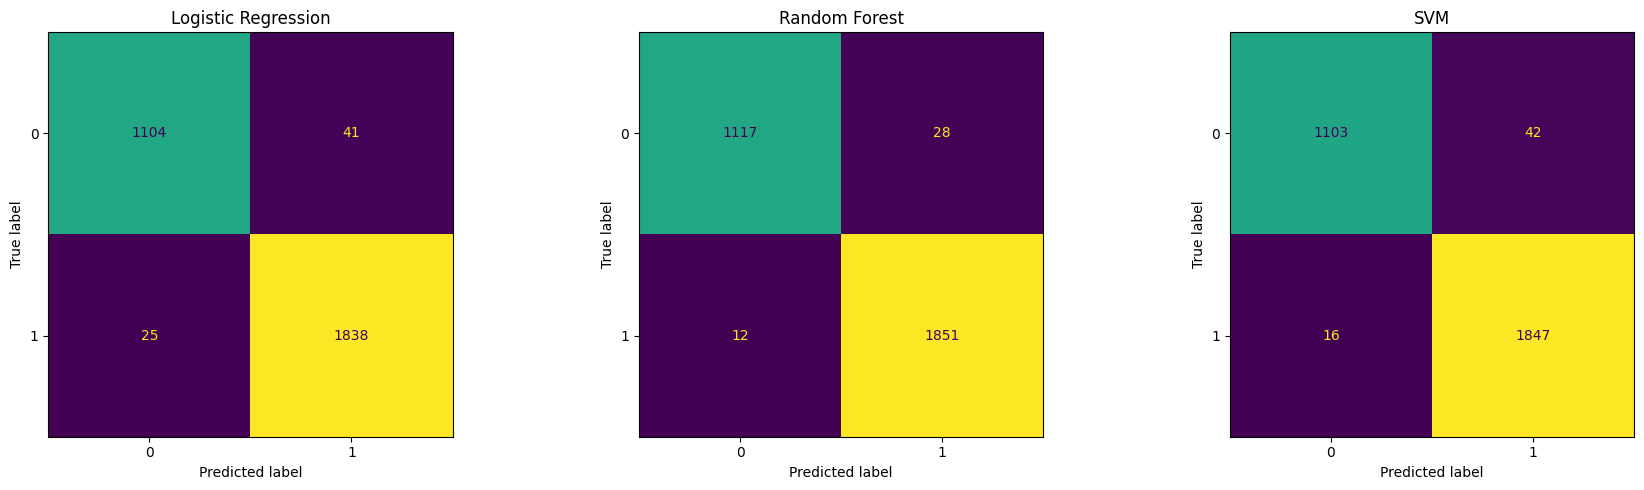

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

fig, axes = plt.subplots(1, 3, figsize=(18,5))

cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_rf = confusion_matrix(y_test, y_pred_rf)
cm_svm = confusion_matrix(y_test, y_pred_svm)

ConfusionMatrixDisplay(cm_lr).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Logistic Regression")

ConfusionMatrixDisplay(cm_rf).plot(ax=axes[1], colorbar=False)
axes[1].set_title("Random Forest")

ConfusionMatrixDisplay(cm_svm).plot(ax=axes[2], colorbar=False)
axes[2].set_title("SVM")

plt.tight_layout()
plt.show()

Metrics

In [ ]:
results = pd.DataFrame({
    "Model": models,
    "Accuracy": accuracies,
    "Precision": precision_scores,
    "Recall": recall_scores,
    "F1-score": f1_scores
})

print(results)

                 Model  Accuracy  Precision    Recall  F1-score
0  Logistic Regression  0.978059   0.978180  0.986581  0.982362
1        Random Forest  0.986702   0.985098  0.993559  0.989311
2                  SVM  0.980718   0.977766  0.991412  0.984542


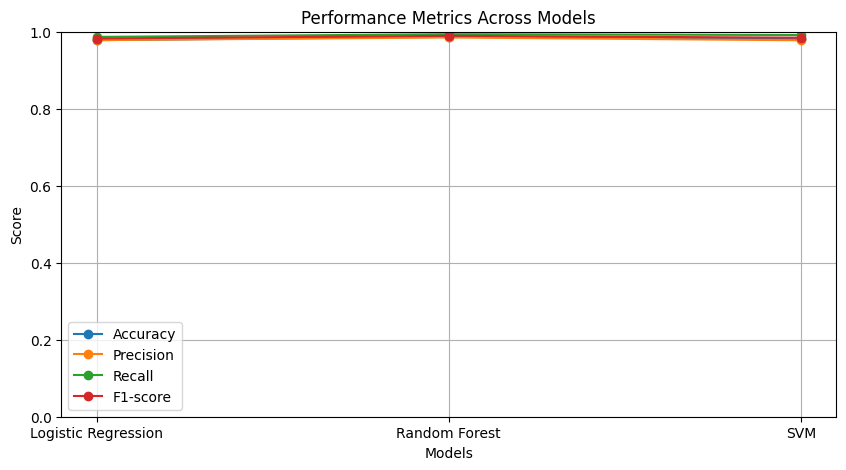

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(models, accuracies, marker='o', label='Accuracy')
plt.plot(models, precision_scores, marker='o', label='Precision')
plt.plot(models, recall_scores, marker='o', label='Recall')
plt.plot(models, f1_scores, marker='o', label='F1-score')

plt.title("Performance Metrics Across Models")
plt.xlabel("Models")
plt.ylabel("Score")
plt.ylim(0, 1.0)
plt.legend()
plt.grid(True)
plt.show()

**Lab Logbook requirement**: Provide a graph comparing the performance of the AI model that you have developed.